<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">Detecção de Anomalia</h1>
</div>

# Introdução
Este conjunto de dados contém informações transacionais destinadas à análise e detecção de potenciais atividades fraudulentas. Os dados incluem diversos atributos que fornecem insights sobre o comportamento transacional, perfis de clientes e outros detalhes contextuais, tornando-os adequados para a aplicação de diferentes técnicas de análise e detecção de anomalias.

# Importando Bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.analysis_utils as func

import warnings
warnings.filterwarnings("ignore")

#Configuração do matplotlib
plt.style.use('default')
palette = ["#3B3936","#B2BEBF","#889C9B","#486966", "#BD2A2E"]

<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">1 Importanto Dataset</h1>
</div>

In [3]:
df = pd.read_csv("data/bank_transactions_data_2.csv")
display(df)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


## 1.1 Descrição do Dataset

Este conjunto de dados oferece uma visão detalhada do comportamento transacional e dos padrões de atividade financeira, ideal para explorar a detecção de fraudes e a identificação de anomalias. Contém 2.512 amostras de dados de transações, abrangendo diversos atributos de transação, dados demográficos de clientes e padrões de uso. 

- **TransactionID**: Identificador alfanumérico único para cada transação.
- **AccountID**: Identificador único para cada conta, com múltiplas transações por conta.
- **TransactionAmount**: Valor monetário de cada transação, variando de pequenas despesas do dia a dia a compras maiores.
- **TransactionDate**: Registro de data e hora de cada transação.
- **TransactionType**: Campo categórico que indica transações de 'Crédito' ou 'Débito'.
- **Location**: Localização geográfica da transação, representada por nomes de cidades dos EUA.
- **DeviceID**: Identificador alfanumérico para dispositivos usados ​​para realizar a transação.
- **IP Address**: Endereço IPv4 associado à transação, com alterações ocasionais para algumas contas.
- **MerchantID**: Identificador único para comerciantes, mostrando os comerciantes preferenciais e os que apresentam discrepâncias em cada conta.
- **AccountBalance**: Saldo da conta após a transação, com correlações lógicas baseadas no tipo e valor da transação.
- **PreviousTransactionDate**: Registro de data e hora da última transação da conta, que auxilia no cálculo da frequência de transações.
- **Channel**: Canal através do qual a transação foi realizada - **Online, ATM (Caixa eletrônico), Branch (Agência Bancária)**.
- **CustomerAge**: Idade do titular da conta, com agrupamentos lógicos baseados na ocupação.
- **CustomerOccupation**: Profissão do titular da conta, **Médico, Engenheiro, Estudante, Aposentado**, refletindo os padrões de renda.
- **TransactionDuration**: Duração da transação em segundos, variando conforme o tipo de transação.
- **LoginAttempts**: Número de tentativas de login antes da transação, sendo que valores mais altos indicam possíveis anomalias.

In [4]:
func.df_summary_report(df)

,Coluna,Tipo,Quantidade de Dados Não Vazios,Quantidade de Dados Vazios,Valores Únicos,Valor mais Frequente,Frequência,Porcentagem de Unicidade,Porcentagem de Valor Vazios (%),Consumo de Memória - Total: 1.63 (MB)
0,TransactionID,str,2512,0,2512,TX000001,1,100.00,0.00,0.136551
1,AccountID,str,2512,0,495,AC00202,12,19.71,0.00,0.134155
2,TransactionAmount,float64,2512,0,2455,11.460000,3,97.73,0.00,0.019165
3,TransactionDate,str,2512,0,2512,2023-01-02 16:00:06,1,100.00,0.00,0.162903
4,TransactionType,str,2512,0,2,Debit,1944,0.08,0.00,0.129906
5,Location,str,2512,0,43,Fort Worth,70,1.71,0.00,0.138243
6,DeviceID,str,2512,0,681,D000142,9,27.11,0.00,0.134155
7,IP Address,str,2512,0,592,200.136.146.93,13,23.57,0.00,0.149158
8,MerchantID,str,2512,0,100,M026,45,3.98,0.00,0.126968
9,Channel,str,2512,0,3,Branch,868,0.12,0.00,0.129376


Alguns dados estão com a tipagem errada o que pode ocasionar em erros quando formos manipular esses dados.

In [5]:
# Converte as coluna do tipo data e category para o dtype certo 
colunas_data = ["TransactionDate", "PreviousTransactionDate"]
df[colunas_data] = df[colunas_data].apply(pd.to_datetime, errors = "coerce")

colunas_cat = ["TransactionType", "Channel", "CustomerOccupation"]
df[colunas_cat] = df[colunas_cat].astype("category")

func.df_summary_report(df)

,Coluna,Tipo,Quantidade de Dados Não Vazios,Quantidade de Dados Vazios,Valores Únicos,Valor mais Frequente,Frequência,Porcentagem de Unicidade,Porcentagem de Valor Vazios (%),Consumo de Memória - Total: 0.96 (MB)
0,TransactionID,str,2512,0,2512,TX000001,1,100.00,0.00,0.136551
1,AccountID,str,2512,0,495,AC00202,12,19.71,0.00,0.134155
2,TransactionAmount,float64,2512,0,2455,11.460000,3,97.73,0.00,0.019165
3,TransactionDate,datetime64[us],2512,0,2512,2023-01-02 16:00:06,1,100.00,0.00,0.019165
4,TransactionType,category,2512,0,2,Debit,1944,0.08,0.00,0.002500
5,Location,str,2512,0,43,Fort Worth,70,1.71,0.00,0.138243
6,DeviceID,str,2512,0,681,D000142,9,27.11,0.00,0.134155
7,IP Address,str,2512,0,592,200.136.146.93,13,23.57,0.00,0.149158
8,MerchantID,str,2512,0,100,M026,45,3.98,0.00,0.126968
9,Channel,category,2512,0,3,Branch,868,0.12,0.00,0.002550


O dataset possui 2512 entradas distribuídas em 16 colunas, sendo composto por dados categóricos e numéricos, o que possibilita a análise de padrões relacionados a transações, dispositivos e métricas quantitativas.

Observa-se que não há valores nulos, e que existem informações temporais, como datas e duração das transações, permitindo análises de séries temporais.

Além disso, o dataset inclui dados demográficos dos clientes, como idade e ocupação, que podem revelar tendências comportamentais específicas entre diferentes grupos.

Também estão presentes informações sobre tentativas de login e localização das transações, que podem ser relevantes para a identificação de possíveis fraudes.

In [6]:
estatisticas = df.describe()
estatisticas.style.background_gradient(cmap="Blues")

,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512.000000,2512
mean,297.593778,2023-07-05 20:32:10.826433,44.673965,119.643312,1.124602,5114.302966,2024-11-04 08:09:22.219745
min,0.260000,2023-01-02 16:00:06,18.000000,10.000000,1.000000,101.250000,2024-11-04 08:06:23
25%,81.885000,2023-04-03 16:22:05.750000,27.000000,63.000000,1.000000,1504.370000,2024-11-04 08:07:53
50%,211.140000,2023-07-07 17:49:43.500000,45.000000,112.500000,1.000000,4735.510000,2024-11-04 08:09:22
75%,414.527500,2023-10-06 18:40:53.500000,59.000000,161.000000,1.000000,7678.820000,2024-11-04 08:10:53.250000
max,1919.110000,2024-01-01 18:21:50,80.000000,300.000000,5.000000,14977.990000,2024-11-04 08:12:23
std,291.946243,nan,17.792198,69.963757,0.602662,3900.942499,nan


Analisando os dados estatiticos vemos que o valor médio de transação de 300 e um desvio padrão de 291,94 indicando uma grande variação nos valores de transações. Quando observamos os valor mínimos e máximo notamos uma enorme discrepância nos valores, sugerindo a presença de outliers no nosso conjunto de dados.

Em relação à idade dos clientes, a média é de aproximadamente 44 anos, com valores entre 18 e 80 anos, evidenciando uma ampla faixa etária. Isso possibilita a segmentação de clientes para análise de comportamento financeiro.

A duração média das transações é aproximante 2 minutos (119 segundos), e o tempo máximo de 5 minutos (300 segundos) está diferença pode esta ligada ao tipo de transação, canal, potencial atividade fraudulenta ou dificuldade de realizar a transação.

As tentativas de login variam entre 1 e 5, sendo que valores mais altos podem indicar risco de comprometimento da conta. Além disso, a variação significativa nos saldos das contas sugere diferentes perfis financeiros, o que pode influenciar o comportamento transacional.

A presença de valores discrepantes, tanto no valor das transações quanto nas tentativas de login, indica que técnicas de detecção de anomalias podem ser eficazes na identificação de possíveis fraudes.


<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">2 Análise Exploratória dos Dados</h1>
</div>

## 2.1 Introdução
Antes de avançarmos para análises mais complexas, é importante compreender a composição do conjunto de dados e identificar as principais características dos registros disponíveis. Nesta etapa inicial da Análise Exploratória de Dados (EDA), serão examinadas algumas variáveis categóricas relevantes para o contexto das transações financeiras.

Em particular, serão analisados o tipo de transação realizada (crédito ou débito), o canal utilizado para acesso à conta (agência, caixa eletrônico ou plataforma online) e a ocupação profissional dos clientes.

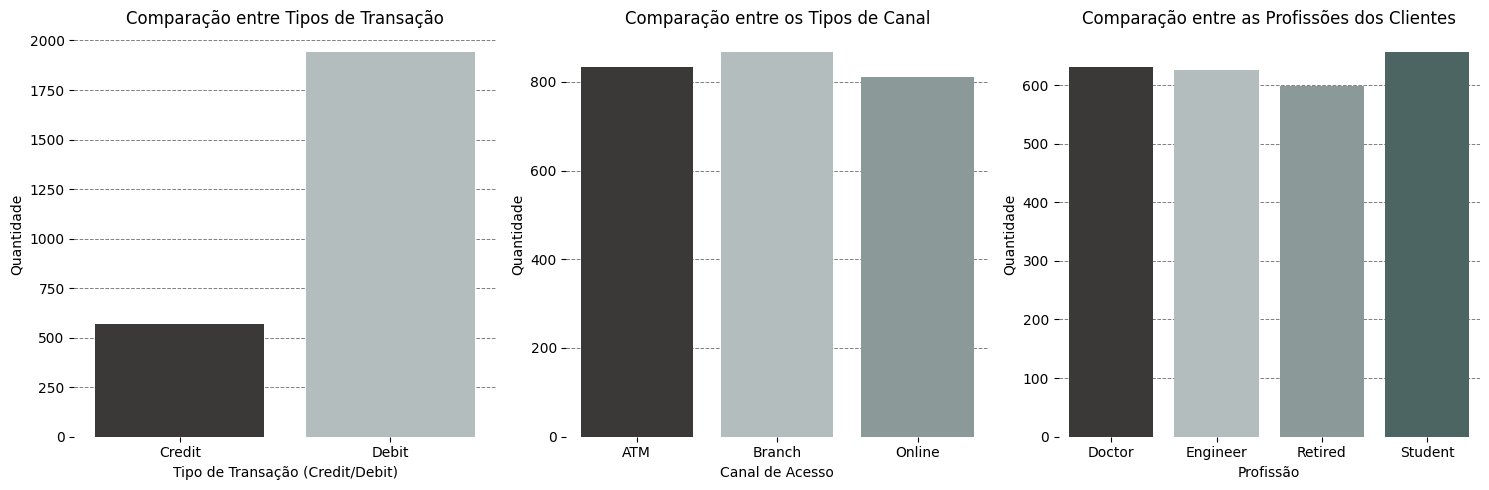

In [7]:
func.plot_categorical_distributions(df, palette)

A análise das variáveis categóricas revela que as transações do tipo débito são mais frequentes do que as transações de crédito, indicando uma predominância desse tipo de operação na base de dados. Em relação aos canais de acesso, observa-se uma distribuição relativamente equilibrada entre agência, caixa eletrônico (ATM) e plataforma online, sem a presença de um canal claramente dominante.

Quanto ao perfil profissional dos clientes, a distribuição também se mostra bastante homogênea, embora o grupo de estudantes apresente a maior frequência de registros, enquanto aposentados representam a menor parcela da amostra. De modo geral, não são observados desbalanceamentos expressivos entre as categorias analisadas, o que sugere uma boa representatividade dos diferentes perfis de clientes e canais de transação presentes no dataset.

## 2.2 Distribuição dos Valores e Saldo

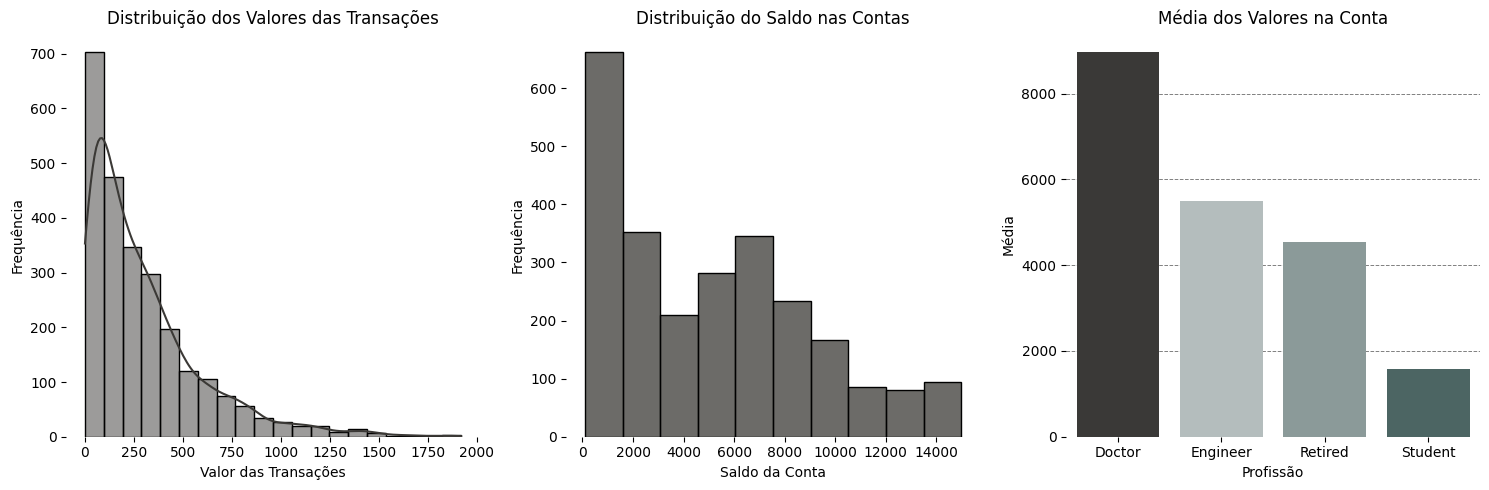

In [8]:
func.plot_financial_distributions(df, palette)

A distribuição dos valores das transações apresenta uma forte assimetria positiva (cauda à direita), indicando que a maior parte das operações financeiras envolve valores relativamente baixos. À medida que o valor das transações aumenta, sua frequência diminui consideravelmente, embora existam alguns registros com valores significativamente superiores à média.

A distribuição dos saldos das contas também apresenta assimetria à direita, evidenciando que a maioria dos clientes mantém saldos mais modestos, enquanto uma parcela menor concentra valores substancialmente mais elevados.

Ao segmentar os saldos médios por ocupação profissional, observa-se uma diferença expressiva entre os grupos analisados. Clientes com ocupação "Doctor" apresentam o maior saldo médio, enquanto "Student" possui o menor. As categorias "Engineer" e "Retired" situam-se em uma faixa intermediária. Essas diferenças sugerem que a ocupação profissional pode estar associada ao perfil financeiro dos clientes e, consequentemente, influenciar o comportamento transacional observado no dataset.

## 2.3 Análise da Duração, Tentativa e Idade

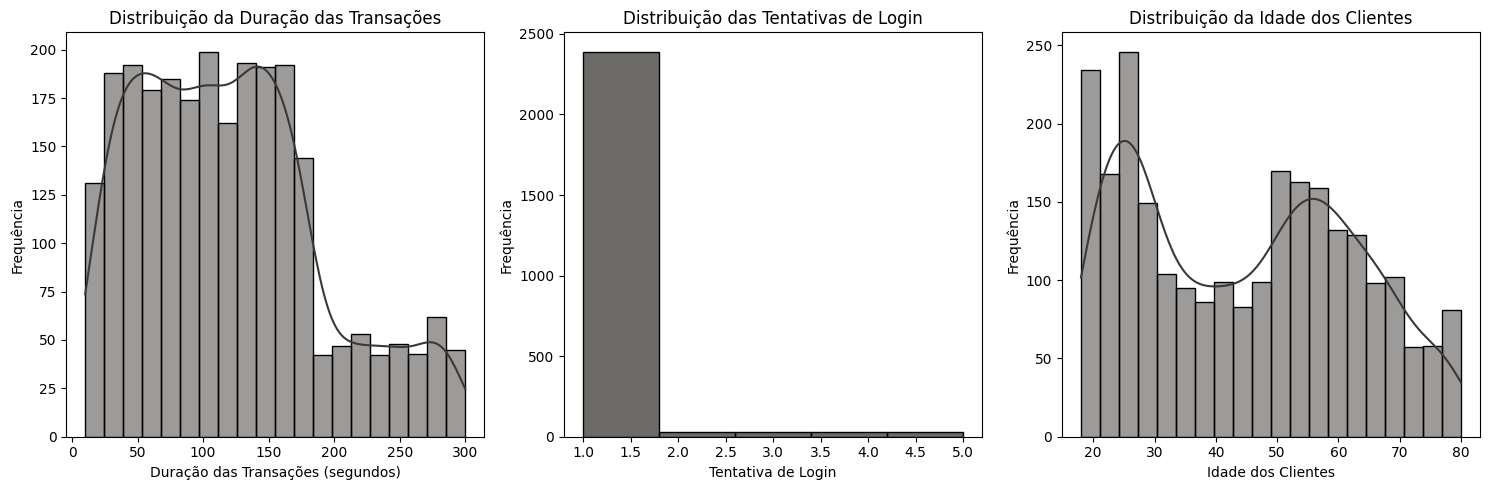

In [9]:
func.analyze_customer_behavior(df)

A distribuição da duração das transações apresenta uma concentração maior entre aproximadamente 30 e 180 segundos, sugerindo que a maioria das operações é concluída em um intervalo de tempo relativamente consistente. Observa-se também uma redução gradual na frequência das transações mais longas. Essas ocorrências menos frequentes podem merecer investigação adicional para verificar se representam comportamentos excepcionais ou apenas variações normais do processo transacional.

Em relação às tentativas de login, a distribuição é fortemente concentrada em apenas uma tentativa, indicando que a maior parte dos clientes consegue acessar suas contas sem dificuldades. 

A distribuição da idade dos clientes apresenta dois agrupamentos mais evidentes: um concentrado entre aproximadamente 20 e 35 anos e outro entre 50 e 65 anos. Esse comportamento sugere uma distribuição bimodal, indicando a presença de dois perfis etários predominantes na base de clientes. A existência desses grupos distintos pode influenciar padrões de uso, comportamento transacional e características financeiras observadas ao longo da análise.

<Figure size 1200x400 with 0 Axes>

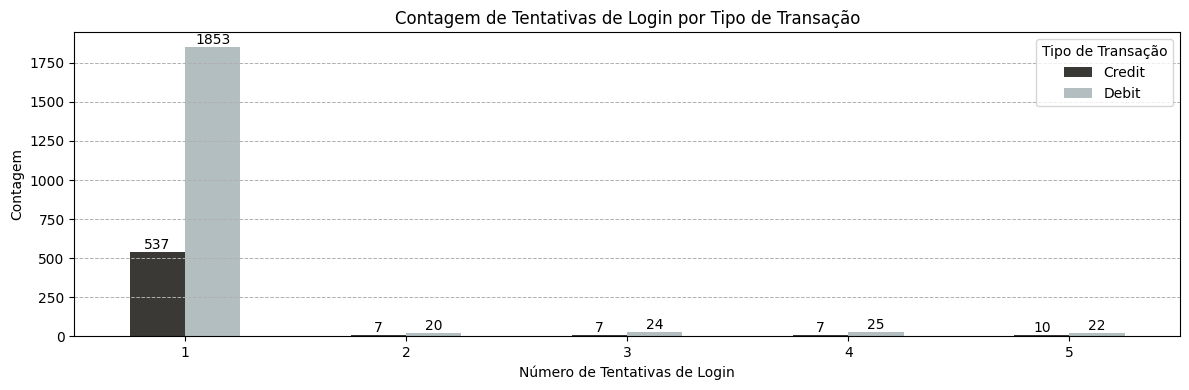

In [10]:
func.plot_loggin_attempts(df, palette)

Analisando este outro gráfico fica bem claro a distruição das tentativas de login das contas se concentra em apenas uma tentativa e também podemos observar qual tipo de transação é realizada.

O número reduzido de registros com múltiplas tentativas sugere que falhas de autenticação são eventos relativamente raros na base analisada. Em um contexto de detecção de anomalias, transações associadas a um número elevado de tentativas de login podem representar um comportamento de interesse para análises futuras.

## 2.4 Transação por Profissão e Canal de Acesso

A análise conjunta do tipo de transação, ocupação profissional e canal de acesso evidencia um padrão consistente em toda a base de dados: as transações de débito são significativamente mais frequentes do que as transações de crédito, independentemente da profissão do cliente ou do canal utilizado.

In [11]:
df.groupby(["TransactionType", "CustomerOccupation"])["Channel"].value_counts().to_frame().style.background_gradient(cmap='Blues')

Entre as operações de crédito, observa-se uma preferência pelos canais Agência (Branch) e Online, enquanto o uso de caixas eletrônicos (ATM) ocorre com menor frequência em todos os grupos profissionais. Já nas transações de débito, os três canais apresentam volumes mais equilibrados, embora o ATM registre uma participação ligeiramente superior em algumas categorias.

Quando observamos o perfil profissional dos clientes, nota-se que as diferenças entre as ocupações são relativamente pequenas. Médicos, engenheiros, aposentados e estudantes apresentam comportamentos semelhantes em relação à escolha dos canais de acesso e ao tipo de transação realizado. Essa homogeneidade sugere que, em um primeiro momento, a profissão do cliente não parece ser um fator determinante para explicar variações significativas no comportamento transacional.

In [12]:
porcentagem_channel =  pd.crosstab(
    [df['TransactionType'], df['CustomerOccupation']],
    df['Channel'],
    normalize='index').mul(100)

porcentagem_channel.style.background_gradient(cmap="Blues")

De forma geral, os resultados indicam que o tipo de transação exerce maior influência sobre o volume de operações do que a ocupação profissional ou o canal de acesso. Para a etapa de detecção de anomalias, isso sugere que padrões incomuns provavelmente estarão associados a características específicas das transações, como valor, horário ou frequência de uso, e não apenas às categorias analisadas nesta seção.

In [13]:
top_valor_conta = df.groupby('CustomerOccupation').agg(
    Qtd_Transacoes=('TransactionID', 'count'),
    Valor_Medio=('AccountBalance', 'mean'),
    Mediana = ("AccountBalance", "median"),
    Valor_Total=('AccountBalance', 'sum')).nlargest(10, 'Valor_Total')
top_valor_conta.style.background_gradient(cmap="Blues")

,Qtd_Transacoes,Valor_Medio,Mediana,Valor_Total
CustomerOccupation,,,,
Doctor,631,8978.994057,9662.880000,5665745.250000
Engineer,625,5486.406064,5677.520000,3429003.790000
Retired,599,4542.157012,4574.430000,2720752.050000
Student,657,1570.209985,1081.970000,1031627.960000


Ao analisar o saldo das contas por ocupação profissional, observa-se uma clara diferença entre os grupos de clientes. Os estudantes apresentam os menores valores de saldo, com média de aproximadamente 1.570 e mediana de 1.082, enquanto os médicos concentram os maiores recursos financeiros, registrando média próxima de 8.979 e mediana de 9.663.

Engenheiros e aposentados ocupam uma posição intermediária, com saldos médios relativamente próximos entre si. Além disso, a quantidade de registros por profissão é bastante equilibrada, indicando que as comparações realizadas não são significativamente influenciadas por desbalanceamentos na amostra.

Outro aspecto relevante é a relação entre média e mediana. Para médicos, engenheiros e aposentados, ambas as métricas apresentam valores próximos, sugerindo distribuições relativamente estáveis. Já entre os estudantes, a média é consideravelmente superior à mediana, indicando a presença de alguns clientes com saldos elevados que aumentam a média do grupo. Esse comportamento sugere uma maior dispersão dos saldos nessa categoria e pode justificar uma investigação mais detalhada dos valores extremos.

Ao analisar o valor médio das transações por profissão, observa-se:

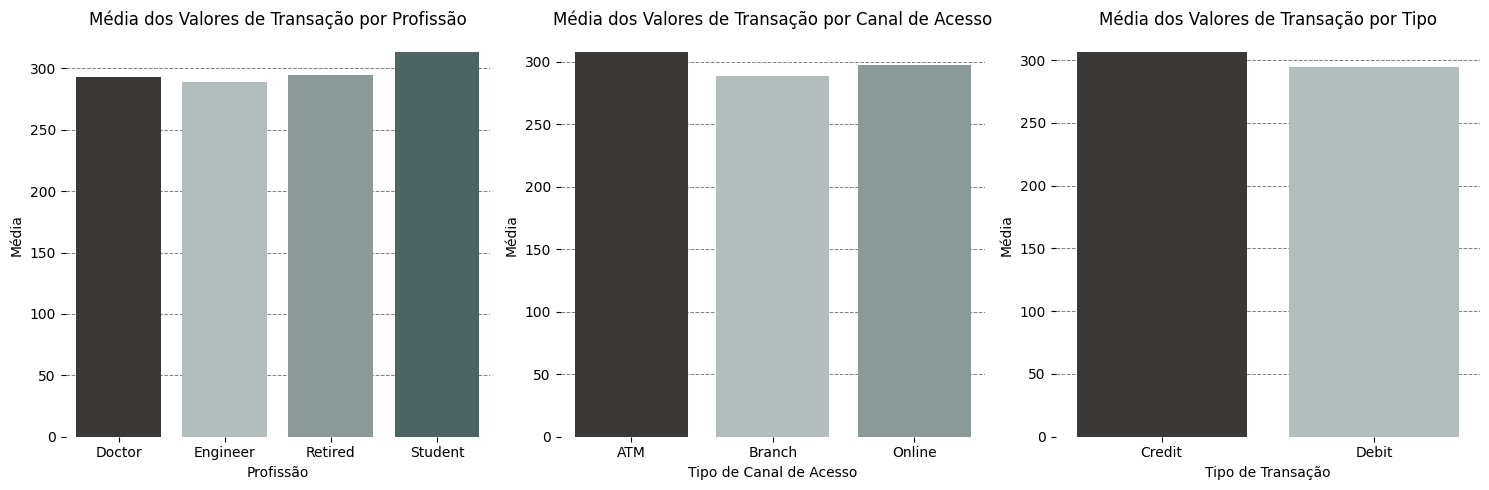

In [14]:
func.mean_transaction(df, palette)

Os diferentes grupos apresentam médias bastante próximas, variando apenas ligeiramente entre si. Os estudantes registram a maior média de valor transacionado, enquanto engenheiros apresentam a menor, porém a diferença entre os grupos não é suficientemente expressiva para indicar um comportamento discrepante.

Esse padrão de homogeneidade também é observado quando a análise é segmentada por canal de acesso e tipo de transação. Transações realizadas em caixas eletrônicos (ATM) apresentam uma média ligeiramente superior às realizadas em agências físicas (Branch) e canais online, enquanto operações de crédito possuem valor médio um pouco maior que operações de débito. No entanto, as diferenças permanecem relativamente pequenas.

Esses resultados sugerem que, considerando apenas o valor médio das transações, não existem evidências de comportamentos anômalos ou grupos claramente distintos. Dessa forma, a investigação de possíveis anomalias deverá considerar outras variáveis e métricas, como dispersão dos valores, frequência de transações, duração das operações ou combinações entre múltiplos atributos.

In [15]:
pivot = pd.pivot_table(
    df,
    index="CustomerOccupation",
    columns="Channel",
    values="TransactionDuration",
    aggfunc=["count", "mean"]
)

media_idade = df.groupby("CustomerOccupation")["CustomerAge"].mean()

pivot[("CustomerAge", "mean")] = media_idade

pivot = pivot.rename(columns={
    "count": "Quantidade de Acesso",
    "mean": "Média de Tempo em Segundos",
    "CustomerAge": "Idade"
}, level=0)

pivot = pivot.rename(columns={
    "mean": "Média"
}, level=1)

pivot.style.background_gradient(cmap="Blues")

A distribuição dos acessos entre os canais ATM, Agência (Branch) e Online apresenta um padrão relativamente equilibrado para todas as ocupações analisadas. No entanto, observa-se que estudantes e médicos realizam uma quantidade ligeiramente maior de acessos por meio de caixas eletrônicos (ATM), enquanto clientes aposentados apresentam menor utilização dos canais digitais.

Em relação ao tempo médio de interação com cada canal, destaca-se o grupo de aposentados, que registra o maior tempo médio de atendimento em agências bancárias. Esse comportamento pode indicar uma maior dependência do atendimento presencial ou uma menor familiaridade com canais digitais quando comparado aos demais perfis de clientes.

Outro aspecto relevante é que estudantes apresentam o maior tempo médio de utilização do canal online, enquanto médicos e engenheiros distribuem seu tempo de forma mais homogênea entre os diferentes canais de acesso. Essas diferenças sugerem que fatores demográficos, como idade e perfil profissional, podem influenciar a forma como os clientes interagem com os serviços bancários.

Do ponto de vista da detecção de anomalias, esses padrões são importantes para estabelecer um comportamento esperado para cada grupo de clientes. Por exemplo, uma transação online de longa duração realizada por um cliente aposentado pode representar um evento mais incomum do que a mesma operação realizada por um estudante, tornando a ocupação e o canal de acesso variáveis potencialmente úteis para a identificação de comportamentos atípicos.

## 2.5 Análise das Localidades
Algo que pode ser útil para a análise é visualizar quais localicades possuem maior valor total e qual possui maior valor médio de transações. Abaixo na primeira tabela tabela nos temos uma que mostra o Top 10 cidades com maior valor total e a segunda tabela com maior valor médio.

In [16]:
top_local = df.groupby('Location').agg(
    Qtd_Transacoes=('TransactionID', 'count'),
    Valor_Medio=('TransactionAmount', 'mean'),
    Valor_Total=('TransactionAmount', 'sum')).nlargest(10, 'Valor_Total')
top_local.style.background_gradient(cmap="Blues")

,Qtd_Transacoes,Valor_Medio,Valor_Total
Location,,,
Austin,59,385.438983,22740.900000
Oklahoma City,68,319.353529,21716.040000
Memphis,63,336.040159,21170.530000
Fort Worth,70,296.810571,20776.740000
Detroit,63,327.139048,20609.760000
Jacksonville,60,341.991167,20519.470000
Tucson,67,305.369552,20459.760000
Colorado Springs,60,339.077167,20344.630000
San Jose,59,341.150339,20127.870000


In [17]:
top_local_media = df.groupby('Location').agg(
    Qtd_Transacoes=('TransactionID', 'count'),
    Valor_Medio=('TransactionAmount', 'mean'),
    Valor_Total=('TransactionAmount', 'sum')).nlargest(10, 'Valor_Medio')
top_local_media.style.background_gradient(cmap="Blues")

,Qtd_Transacoes,Valor_Medio,Valor_Total
Location,,,
Austin,59,385.438983,22740.900000
El Paso,46,369.511957,16997.550000
Columbus,54,353.318148,19079.180000
Washington,48,351.032083,16849.540000
Phoenix,55,346.630182,19064.660000
Jacksonville,60,341.991167,20519.470000
San Jose,59,341.150339,20127.870000
Colorado Springs,60,339.077167,20344.630000
Portland,42,338.621667,14222.110000


A primeira coisa que podemos notar é qua cidade de Austin aparece no top 1 das duas tabelas, porém ela não possui a maior quantidade de transações, ela lidera tanto em valor total quanto valor médio, isso pode significar que nesta cidade as transações tendem a ser mais altas, mesmo sem ser a cidade com maior volume de operações. Para este projeto, isso faz de Austin uma localidade que merece maior atenção. 

Outra cidade que merece destaque é Fort Worth, possui a maior quantidade de transações, porém ocupa apenas a quarta posição em valor total, isso pode significar que suas operações, em média são de valores menores quando comparadas às de Austin.

El Paso também chama bastante atenção, pois ela aparece em segunda posição em valor médio, mas nem sequer figura entre as dez maiores em valor total, isso pode significar poucas transações com valores moderados.

Para a detecção de anomalias, essa distinção é particularmente relevante. Localidades que combinam altos valores médios e elevados volumes financeiros, como Austin, podem representar áreas de maior exposição financeira e merecem monitoramento contínuo. Da mesma forma, localidades com poucas transações, mas valores médios excepcionalmente elevados, podem indicar padrões incomuns que justificam uma investigação mais detalhada.

Além de apenas analisar a localidade e visualizar quais os maiores valores totais e médios, vamos acrescentar a ocupação dos clientes e identificar quais perfis de clientes concentram os maiores volumes financeiros em cada cidade.

In [18]:
top_local_occupation = df.groupby(["Location", "CustomerOccupation"]).agg(
    Qtd_Transacoes = ('TransactionID', 'count'),
    Valor_Medio = ('TransactionAmount', 'mean'),
    Valor_Total =('TransactionAmount', 'sum')
).nlargest(10, "Valor_Total")
top_local_occupation.style.background_gradient(cmap="Blues")

,,Qtd_Transacoes,Valor_Medio,Valor_Total
Location,CustomerOccupation,,,
San Diego,Student,14,600.215714,8403.020000
Houston,Engineer,23,345.971304,7957.340000
Fort Worth,Student,19,417.227368,7927.320000
Detroit,Doctor,21,371.640952,7804.460000
Los Angeles,Student,23,338.895217,7794.590000
Austin,Student,14,537.095000,7519.330000
Chicago,Retired,23,304.677391,7007.580000
New York,Engineer,18,384.335000,6918.030000
Colorado Springs,Retired,18,381.266111,6862.790000


In [19]:
top_local_occupation_media = df.groupby(["Location", "CustomerOccupation"]).agg(
    Qtd_Transacoes = ('TransactionID', 'count'),
    Valor_Medio = ('TransactionAmount', 'mean'),
    Valor_Total =('TransactionAmount', 'sum')
).nlargest(10, "Valor_Medio")
top_local_occupation_media.style.background_gradient(cmap="Blues")

,,Qtd_Transacoes,Valor_Medio,Valor_Total
Location,CustomerOccupation,,,
San Diego,Student,14,600.215714,8403.020000
Columbus,Doctor,9,593.348889,5340.140000
Austin,Student,14,537.095000,7519.330000
Indianapolis,Student,10,497.816000,4978.160000
Tucson,Retired,13,455.207692,5917.700000
Phoenix,Engineer,13,448.206154,5826.680000
Las Vegas,Student,7,438.634286,3070.440000
Portland,Doctor,8,436.333750,3490.670000
Washington,Engineer,9,430.976667,3878.790000


O primeiro ponto que chama atenção é a cidade de San Diego, ela ocupa a primeira posição nas duas tabelas e esse resultado está associado ao grupo Student (estudante), embora existam apenas 14 transações, elas apresentam um valor médio muito superior as das demais combinações de cidade e ocupação. Esse comportamento pode indicar um padrão específico desse segmento e merece uma análise mais aprofundada para verificar se representa um comportamento esperado ou um possível indício de anomalia.

Austin volta a figurar entre as localidades com maior movimentação financeira mesmo após segmentar os dados por ocupação profissional, indicando que seu destaque não está relacionado apenas ao comportamento agregado da cidade, mas também a um perfil específico de clientes.

Outra análise que podemos fazer é Student(estudante), Engineer(engenheiro) aparecem com mais frequência que Doctor(médico) e Retired(aposentado), isso pode indicar que os maiores volumes financeiros estão concentrados em determinados pergis profissionais.

Agora a análise será feita para o MerchantID.

In [20]:
top_merchant = df.groupby("MerchantID").agg(
    Qtd_Transacoes=('TransactionID', 'count'),
    Valor_Medio=('TransactionAmount', 'mean'),
    Valor_Total=('TransactionAmount', 'sum')
    ).nlargest(10, 'Valor_Total')
top_merchant.style.background_gradient(cmap="Blues")

,Qtd_Transacoes,Valor_Medio,Valor_Total
MerchantID,,,
M026,45,308.114444,13865.150000
M066,34,351.433824,11948.750000
M005,32,346.872813,11099.930000
M048,26,421.338077,10954.790000
M009,30,350.868000,10526.040000
M038,31,336.887419,10443.510000
M013,33,315.646970,10416.350000
M028,33,312.615758,10316.320000
M081,23,441.511739,10154.770000


O comerciante M026 lidera o ranking de valor total, porém seu valor médio por transação de 308.11 não é o maior entre os comerciantes apresentados. Isso indica que o destaque de M026 é consequência principalmente do alto volume de transações, e não necessariamente de operações individuais de grande valor.

Já os comerciantes M081 de média 441.51 e M048 de média 421.33, movimentam menos dinheiro no total que M026, mas suas transações individuais possuem valores maiores. 

In [21]:
top_merchant = df.groupby(["MerchantID", "Location"]).agg(
    Qtd_Transacoes=('TransactionID', 'count'),
    Valor_Medio=('TransactionAmount', 'mean'),
    Valor_Total=('TransactionAmount', 'sum')
    ).nlargest(10, 'Valor_Total')
top_merchant.style.background_gradient(cmap="Blues")

,,Qtd_Transacoes,Valor_Medio,Valor_Total
MerchantID,Location,,,
M020,Austin,2,1275.085000,2550.170000
M026,Washington,3,839.923333,2519.770000
M060,Oklahoma City,3,709.876667,2129.630000
M032,Fort Worth,3,667.273333,2001.820000
M048,Mesa,3,648.840000,1946.520000
M064,San Antonio,2,959.625000,1919.250000
M033,Portland,1,1919.110000,1919.110000
M016,New York,3,633.430000,1900.290000
M060,Austin,2,946.025000,1892.050000


Aqui Austin volta a aperecer, isso normalmente merece destaque. Não significa necessariamente fraude, mas indica que Austin concentra operações financeiras relevantes sob diferentes perspectivas:
- por localização;
- por profissão;
- por comerciante.

Esse padrão sugere que a cidade possui uma atividade financeira mais intensa ou transações de maior valor médio quando comparada às demais localidades.

Outro aspecto relevante é a presença de combinações com poucas transações, porém valores médios significativamente elevados, como o comerciante M020 em Austin. Em um contexto de detecção de anomalias, esse comportamento merece atenção, pois operações isoladas de alto valor podem representar eventos excepcionais que justificam uma investigação mais detalhada.

## 2.6 Análise das Transações ao Longo do Tempo
Além abordagem que podemos utilizar para tentar identificar as transações anomalas é ver o comportamento delas ao longo do tempo e vê suas tendências, sazionalidades.

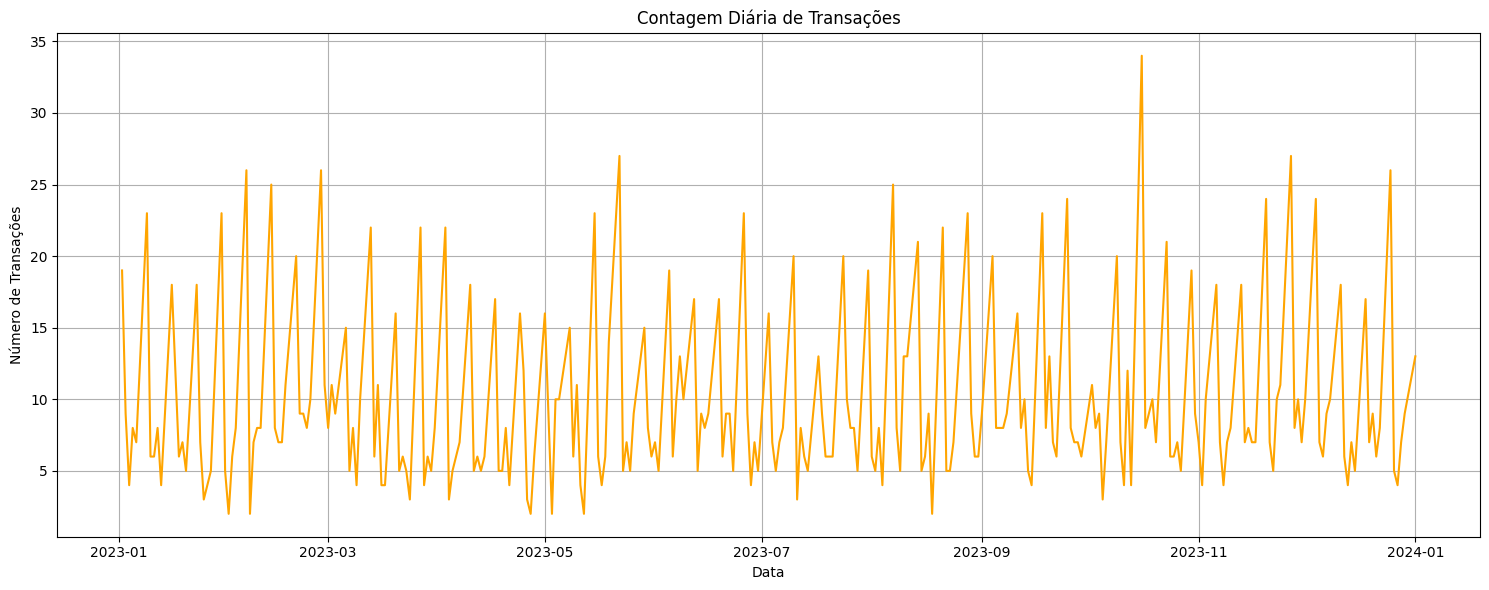

In [22]:
func.transactions_over_time(df)

Ao analisar a série temporal das transações, vemos que não temos evidências visuais de tendência crescente ou decrescente, também não foi identificado um padrão sazonal recorrente, isso indica que a quantidade de transações varia aleatoriamente entre os dias. 
Observa-se um pico isolado de aproximadamente 24 transações em outubro de 2023, caracterizando um possível outlier que merece investigação adicional. 

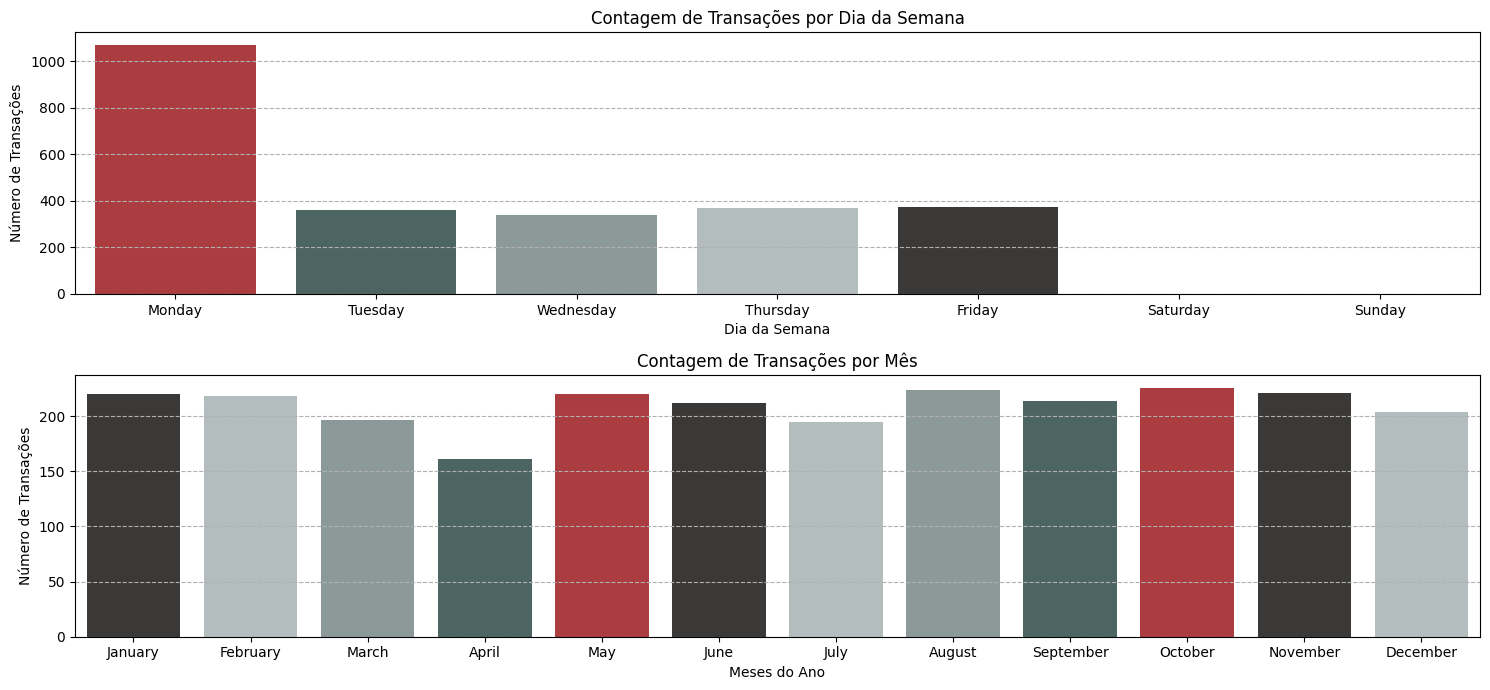

In [23]:
func.plot_transaction(df, palette)

A distribuição mensal das transações permaneceu relativamente estável ao longo do período analisado. Embora alguns meses apresentem pequenas oscilações como por exemplo o mês de abril, que apresentou menor volume de transações, e agosto, outubro e novembro, com valores ligeiramente superiores, também não há evidências visuais de um padrão sazonal consistente. 
O pico observado na série temporal diária durante outubro corresponde a um evento pontual, não sendo suficiente para caracterizar um aumento significativo no volume mensal de transações.

Algo que chama muita atenção neste gráfico que a segunda-feira tem um número muito elevado de transações em relação aos demais deias da semana, podemo confirmar esse valor calculando a média de transações realizadas por dia da semana.

Também não foram registradas transações aos finais de semana, indicando que o conjunto de dados contempla apenas dias úteis.

In [ ]:
daily = df.groupby(df['TransactionDate'].dt.date).size().reset_index(name='Transactions')
daily['Day'] = pd.to_datetime(daily['TransactionDate']).dt.day_name()
daily.groupby('Day')['Transactions'].mean().to_frame().style.background_gradient(cmap="Blues")

,Transactions
Day,
Friday,7.173077
Monday,20.188679
Thursday,7.076923
Tuesday,6.923077
Wednesday,6.557692


Agora podemos ver que a segunda feira possui uma média de transações diárias significativamente maior que os outros dias da semana com 20 transações enquanto os outros dias oscilam entre 6 e 7 movimentações financeiras.

## 2.7 Transações Atípicas
Agora que sabemos a distribuição das transações ao longo da semana e dos meses, podemos ver quais delas podem ser classificadas como atípicas. Para isso irei usar o horário comercial das 9h as 18h e qualquer transação realizada fora desse intervalo, pode representar uma transação anômala. 

Essa definição foi utilizada exclusivamente para fins exploratórios e não caracteriza, por si só, uma atividade fraudulenta.

In [ ]:
# Extrair a hora da transação
df['TransactionHour'] = df['TransactionDate'].dt.hour

# Define horário atípico (outside 9 AM - 6 PM)
hora_atipico = list(range(9,18))

# Filter transactions during horário atípico
transacao_atipica = df[~df['TransactionHour'].isin(hora_atipico)]

print(f"Numéro de transações em horário atípico: {len(transacao_atipica)}")
display(transacao_atipica.head())

Numéro de transaçÕes em horário atípico: 377


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Day_of_Week,Mes,TransactionHour
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,Monday,July,18
17,TX000018,AC00359,492.93,2023-12-14 18:32:14,Debit,Columbus,D000432,114.223.129.47,M059,Online,39,Engineer,234,1,5109.97,2024-11-04 08:11:51,Thursday,December,18
19,TX000020,AC00285,71.48,2023-06-08 18:18:50,Credit,Columbus,D000039,120.170.93.69,M039,Online,18,Student,169,1,6568.59,2024-11-04 08:09:20,Thursday,June,18
21,TX000022,AC00014,85.77,2023-08-11 18:31:31,Debit,Las Vegas,D000268,59.132.247.252,M065,Branch,38,Doctor,93,1,9146.19,2024-11-04 08:08:13,Friday,August,18
22,TX000023,AC00095,52.20,2023-06-06 18:54:15,Debit,Atlanta,D000142,133.63.96.21,M022,Online,39,Engineer,120,1,8974.93,2024-11-04 08:07:01,Tuesday,June,18


In [25]:
transacao_atipica["TransactionType"].value_counts().to_frame().style.background_gradient(cmap="Blues")

,count
TransactionType,
Debit,297
Credit,80


Destas 377 transações atípicas, vemos que 297 são de Débito e apenas 80 de Crédito, isso está de acordo com comportamento de conjunto de dados visto anteriormente.

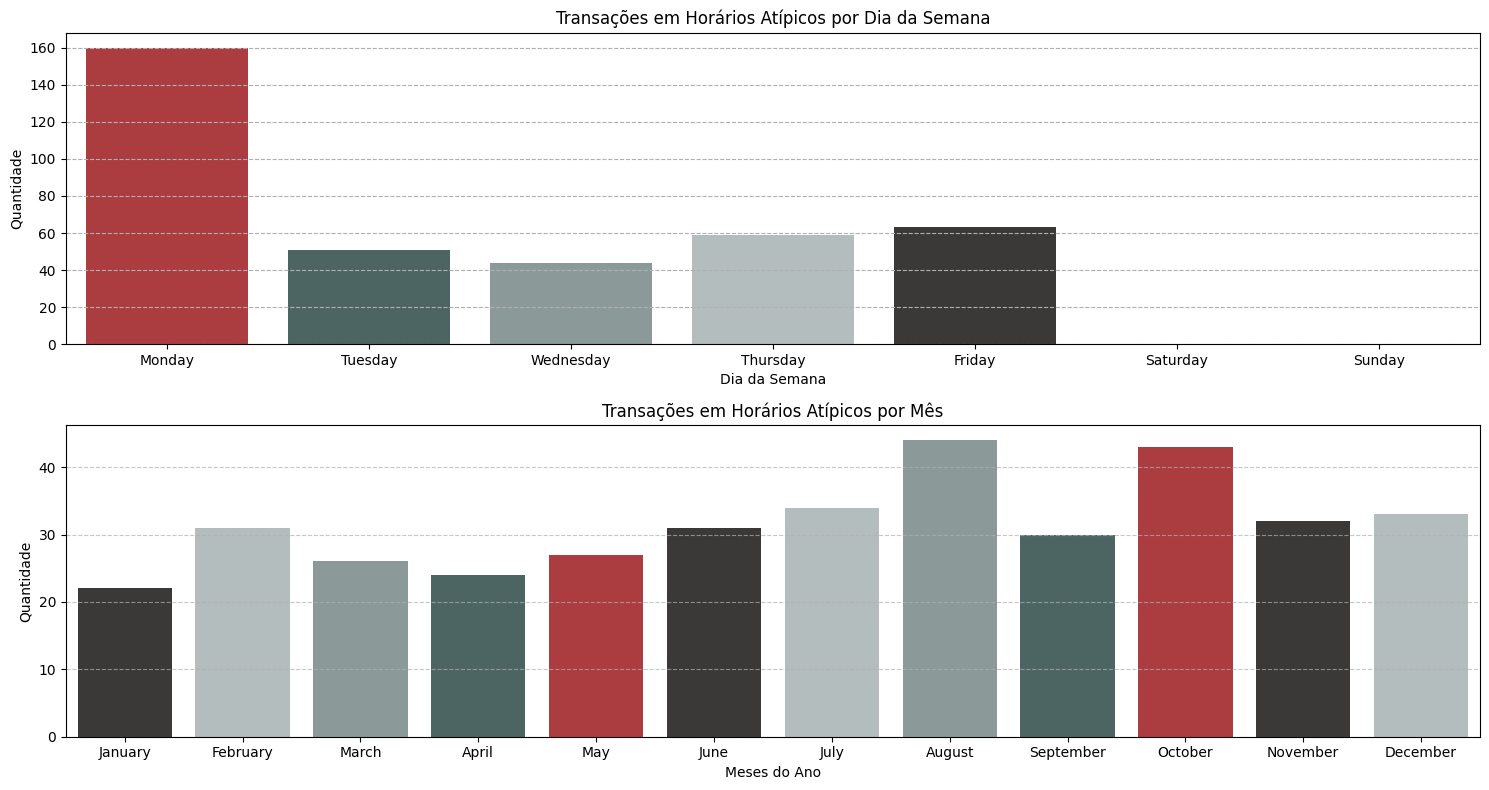

In [26]:
func.plot_atypical_transaction(transacao_atipica, palette)

Observa-se que a maior concentração dessas transações ocorreu nas segundas-feiras, enquanto os demais dias úteis apresentaram volumes significativamente menores e relativamente próximos entre si.

Na análise mensal, a quantidade de transações fora do horário comercial permaneceu relativamente estável ao longo do ano, com um leve aumento entre agosto e outubro, especialmente em agosto, que apresentou o maior número de ocorrências. Apesar dessas oscilações, não há evidências visuais de uma sazonalidade bem definida, sugerindo que as variações observadas fazem parte do comportamento natural do conjunto de dados.

In [27]:
dias_atipicos = (
    transacao_atipica
    .groupby('Day_of_Week')
    .agg(
        Qtd_Transacoes=('TransactionID', 'count'),
        Valor_Medio=('TransactionAmount', 'mean'),
        Valor_Total=('TransactionAmount', 'sum')
    )
    .reset_index()
)
dias_atipicos.style.background_gradient(cmap="Blues")

,Day_of_Week,Qtd_Transacoes,Valor_Medio,Valor_Total
0,Friday,63,286.463492,18047.200000
1,Monday,160,298.760875,47801.740000
2,Thursday,59,203.658644,12015.860000
3,Tuesday,51,320.715882,16356.510000
4,Wednesday,44,241.610909,10630.880000


Ao analisar os valores movimentados por dia da semana, aqui temos que a segunda-feira (Monday) de destaca no número de transações e no valor total, enquanto na terça-feira (Tuesday) apresenta maior valor médio.

Outro fator que pode contribuir para entender essa transações consideradas atípicas é quantidade de tentativas de logar na conta que os usuários realizam.

<Figure size 1200x400 with 0 Axes>

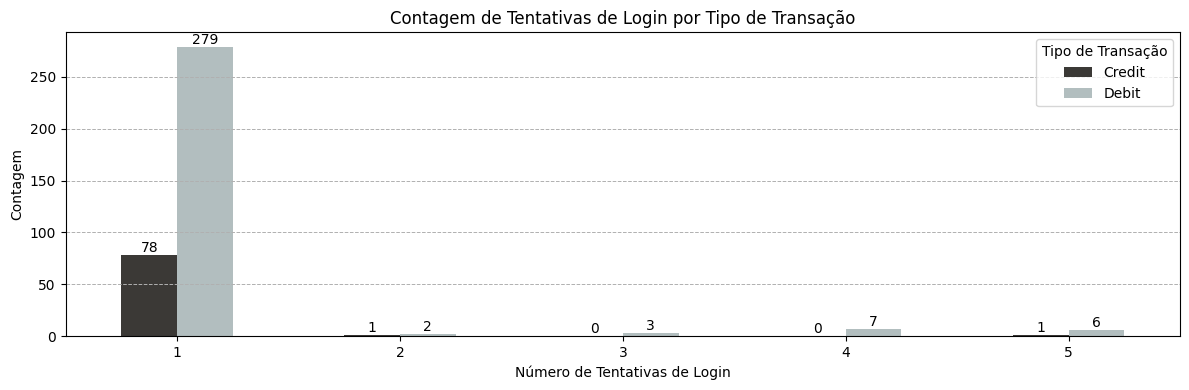

In [28]:
func.plot_loggin_attempts(transacao_atipica, palette)

Olhando o gráfico de tentativa de login por tipo de transação, vemos que a maioria dos usuários realizam apenas uma tentativa de logar na sua conta e que a operação de Débito se destaca, mas não revela algo que seja propriamente uma fraude.

Também podemos analisar o tipo de transação, quem realizou e quais valores são movimentados fora do horário comercial.

In [29]:
valor_atipico = transacao_atipica.groupby(['TransactionType', 'CustomerOccupation']).agg(
    Qtd_Transacoes=('TransactionID', 'count'),
    Valor_Medio=('TransactionAmount', 'mean'),
    Valor_Total=('TransactionAmount', 'sum'),
    Idade=('CustomerAge', 'mean')
)
valor_atipico.style.background_gradient(cmap="Blues")

A análise das transações realizadas fora do horário comercial, segmentadas por tipo de transação e ocupação do cliente, evidencia diferenças importantes no comportamento entre os grupos.

Entre as operações de Crédito, os clientes com ocupação de Engineer e Retired apresentam os maiores valores médios por transação (R$ 308,38 e R$ 311,80, respectivamente). Entretanto, ambos registram apenas 20 transações cada, fazendo com que o valor total movimentado permaneça relativamente baixo quando comparado aos demais grupos. Isso indica que essas categorias realizam menos operações, porém com valores individuais mais elevados.

Nas operações de Débito, observa-se um comportamento distinto. Os Students destacam-se por apresentar uma das maiores quantidades de transações (81), além de um valor médio elevado (R$ 303,62), resultando no maior volume financeiro movimentado entre todos os grupos analisados (R$ 24.593,39). Esse resultado sugere que o elevado valor total não é consequência apenas de transações de alto valor, mas da combinação entre alta frequência de operações e um ticket médio elevado.

Os clientes classificados como Engineers também merecem destaque nas operações de débito, registrando a maior quantidade de transações (82). Apesar de apresentarem um ticket médio inferior ao dos estudantes, o elevado volume de operações faz com que ocupem a segunda posição em valor total movimentado (R$ 21.288,82).

De forma geral, observa-se que o valor total movimentado é fortemente influenciado pela frequência das transações, enquanto o valor médio, isoladamente, não é suficiente para identificar os grupos de maior impacto financeiro.

Além disso o local em que elas ocorrem pode ser de suma importância para entendermos melhor o comportamento dos clientes.

In [30]:
local_atipico = transacao_atipica.groupby(['TransactionType', 'Location']).agg(
    Qtd_Transacoes=('TransactionID', 'count'),
    Valor_Medio=('TransactionAmount', 'mean'),
    Valor_Total=('TransactionAmount', 'sum')
).groupby(level=0, group_keys=False).apply(lambda x: x.nlargest(5, 'Valor_Total'))

local_atipico.style.background_gradient(cmap="Blues")

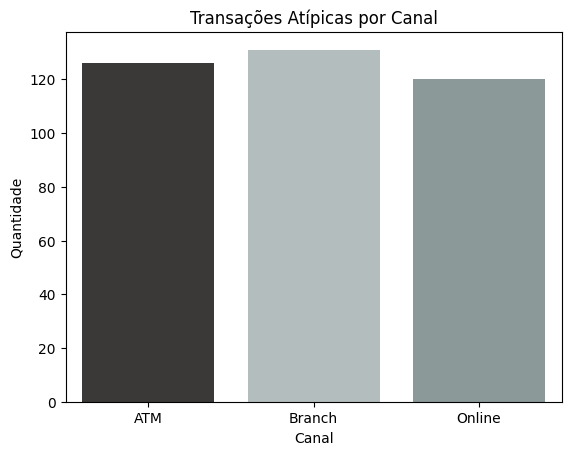

In [31]:
canal_counts = transacao_atipica['Channel'].value_counts()

sns.barplot(x=canal_counts.index,y=canal_counts.values,palette=palette)

plt.title('Transações Atípicas por Canal')
plt.xlabel('Canal')
plt.ylabel('Quantidade')
plt.show()

Visualização das transações ao longo do tempo

<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">3 Detecção de Anomalias</h1>
</div>

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

## 3.1 Isolation Forest

In [35]:
# Mapeamento dos Outliers
outlier_mapping = {
    1: "Normal",
    -1: "Potencial Fraude"
}

# Selação das features relavante para a detecção
features = ['TransactionAmount', 'TransactionDuration', 'AccountBalance', 'LoginAttempts']

X = df[features].copy()

# Padronizando os Dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo Isolatio Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

# Prevendo Anomalias
df["Anomalia_Score"] = iso_forest.decision_function(X_scaled)

# Classificando Anomalias
df["Anomalia"] = iso_forest.predict(X_scaled)

# Traduzindo o resultado
df["Anomalia_Score"] = df["Anomalia"].map(outlier_mapping)

# Filtrando somente as anomalias
potencial_fraude = df[df["Anomalia"] == -1]
print(f"O número de potenciais fraudes detectadas é: {len(potencial_fraude)}")

display(potencial_fraude.head())

O número de potenciais fraudes detectadas é: 126


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Day_of_Week,Mes,TransactionHour,Anomalia_Score,Anomalia
26,TX000027,AC00441,246.93,2023-04-17 16:37:01,Debit,Miami,D000046,55.154.161.250,M029,ATM,...,Student,158,5,673.35,2024-11-04 08:11:38,Monday,April,16,Potencial Fraude,-1
32,TX000033,AC00060,396.45,2023-09-25 16:26:00,Debit,New York,D000621,133.67.250.163,M007,ATM,...,Engineer,168,3,9690.15,2024-11-04 08:11:13,Monday,September,16,Potencial Fraude,-1
85,TX000086,AC00098,1340.19,2023-09-29 17:22:10,Credit,Austin,D000574,165.114.224.47,M012,Online,...,Engineer,30,1,8654.28,2024-11-04 08:06:53,Friday,September,17,Potencial Fraude,-1
91,TX000092,AC00310,223.85,2023-10-02 16:36:10,Debit,Kansas City,D000481,133.223.159.151,M009,ATM,...,Engineer,55,4,2929.91,2024-11-04 08:08:01,Monday,October,16,Potencial Fraude,-1
146,TX000147,AC00385,973.39,2023-08-30 17:23:20,Debit,Sacramento,D000292,202.194.199.70,M026,Branch,...,Retired,296,1,2042.22,2024-11-04 08:11:44,Wednesday,August,17,Potencial Fraude,-1


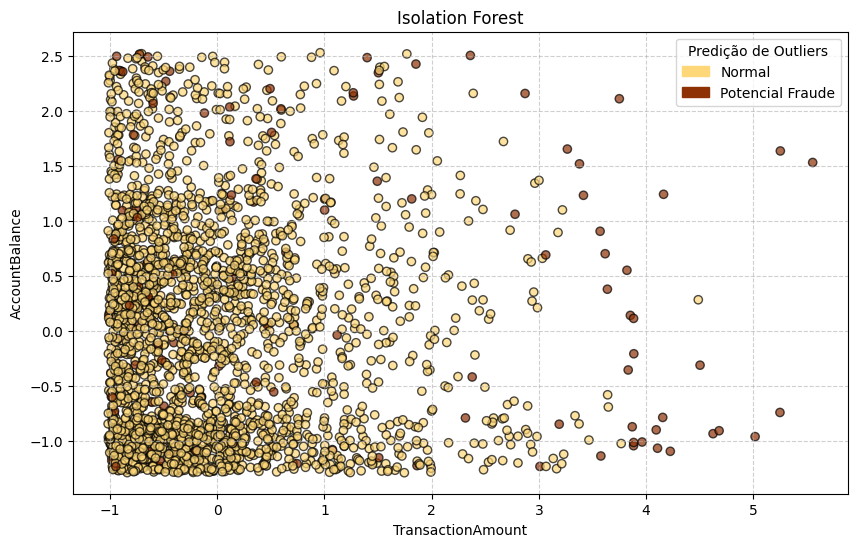

In [37]:
import matplotlib.patches as mpatches

cmap = plt.get_cmap("YlOrBr")
colors = []

for anomaly in df["Anomalia"]:
    if anomaly == -1:
        colors.append(cmap(0.9))
    else:
        colors.append(cmap(0.3))

plt.figure(figsize=(10,6))
scatter = plt.scatter(
    X_scaled[:, 0], # TransactionAmount 
    X_scaled[:, 2], # AccountBalance
    c=colors,
    alpha=0.7,
    edgecolors="k",
    label="Data Points"
)

normal = mpatches.Patch(color=cmap(0.3), label = "Normal")
pot_fraude = mpatches.Patch(color=cmap(0.9), label = "Potencial Fraude")

plt.legend(handles=[normal, pot_fraude], title="Predição de Outliers")

plt.title("Isolation Forest")
plt.xlabel(features[0])
plt.ylabel(features[2])

plt.grid(True, linestyle = "--", alpha=0.6)
plt.show()

<div style="
    background-color: #3D5A73;
    color: white;
    width: 700px;
    height: 120px;                 /* define altura fixa */
    margin: 20px auto;
    border-radius: 15px;
    display: flex;                 /* ativa flexbox */
    align-items: center;           /* centraliza vertical */
    justify-content: center;       /* centraliza horizontal */
">
    <h1 style="margin: 0;">Conclusão</h1>
</div>